In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/luisfelipevendramim/m5-feature-engineered/m5_feature_engineered.csv


**Fluxo do Notebook:**

1. Carregar dados feature engineered
2. Split temporal
3. Baseline Forecast
4. Prophet
5. XGBoost
6. LightGBM
7. Comparação de métricas
8. Feature Importance
9. Conclusões de negócio

**1. Importações**

In [2]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from prophet import Prophet

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

**2. Carregar Base**

In [3]:
df = pd.read_csv(
    "/kaggle/input//datasets/luisfelipevendramim/m5-feature-engineered/m5_feature_engineered.csv",
    parse_dates=["date"]
)

print(df.shape)

df.head()

(4410, 36)


,store_id,cat_id,d,sales,date,wm_yr_wk,weekday,month,year,event_name_1,...,rolling_std_7,rolling_std_28,trend_7,store_encoded,cat_encoded,event_encoded,month_sin,month_cos,dow_sin,dow_cos
0,CA_1,FOODS,d_86,2051,2011-04-24,11113,Sunday,4,2011,OrthodoxEaster,...,605.533374,537.206456,-68.035714,0,0,3,0.866025,-0.500000,-0.781831,0.623490
1,CA_1,FOODS,d_88,1411,2011-04-26,11113,Tuesday,4,2011,Pesach End,...,507.696666,536.695272,-205.214286,0,0,3,0.866025,-0.500000,0.781831,0.623490
2,CA_1,FOODS,d_97,1648,2011-05-05,11114,Thursday,5,2011,Cinco De Mayo,...,369.045100,496.652427,-39.250000,0,0,0,0.500000,-0.866025,0.433884,-0.900969
3,CA_1,FOODS,d_100,2096,2011-05-08,11115,Sunday,5,2011,Mother's day,...,352.672045,489.115078,146.535714,0,0,0,0.500000,-0.866025,-0.781831,0.623490
4,CA_1,FOODS,d_122,2013,2011-05-30,11118,Monday,5,2011,MemorialDay,...,314.769076,375.800549,-193.571429,0,0,1,0.500000,-0.866025,0.000000,1.000000


**3. Escolher Série para Forecast**

In [4]:
series = df[
    (df["store_id"] == "CA_1")
    &
    (df["cat_id"] == "FOODS")
].copy()

series.shape

(147, 36)

**4. Split Temporal**

In [5]:
train = series.iloc[:-28]

test = series.iloc[-28:]

print(train.shape)
print(test.shape)

(119, 36)
(28, 36)


**5. Funções de Métricas**

In [6]:
def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return mae, rmse

**6. Baseline Forecast**

In [7]:
baseline_pred = test["lag_7"]

baseline_mae, baseline_rmse = calculate_metrics(
    test["sales"],
    baseline_pred
)

print(
    baseline_mae,
    baseline_rmse
)

530.5714285714286 763.1864123528405


**7. Prophet**

Preparação:

In [8]:
prophet_df = series[
    ["date", "sales"]
].rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

Treinamento:

In [9]:
prophet_train = prophet_df.iloc[:-28]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_prophet.fit(
    prophet_train
)

00:47:04 - cmdstanpy - INFO - Chain [1] start processing
00:47:04 - cmdstanpy - INFO - Chain [1] done processing


Forecast:

In [10]:
future = model_prophet.make_future_dataframe(
    periods=28
)

forecast = model_prophet.predict(
    future
)

Avaliação:

In [11]:
prophet_pred = forecast["yhat"].tail(28)

prophet_mae, prophet_rmse = calculate_metrics(
    test["sales"],
    prophet_pred
)

print(
    prophet_mae,
    prophet_rmse
)

657.6605303198002 863.565089471206


Visualização:

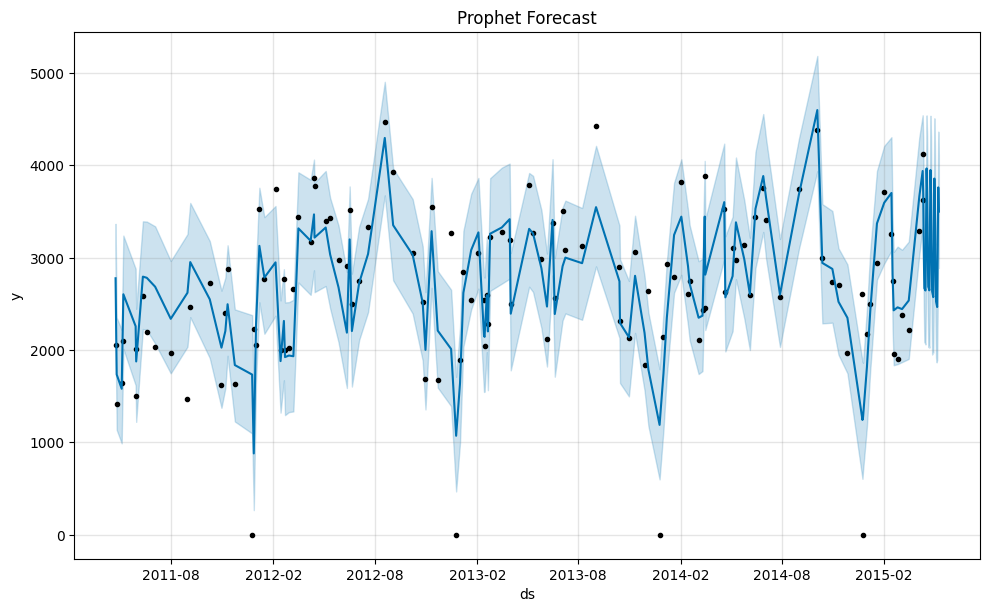

In [12]:
fig = model_prophet.plot(
    forecast
)

plt.title(
    "Prophet Forecast"
)

plt.show()

Componentes:

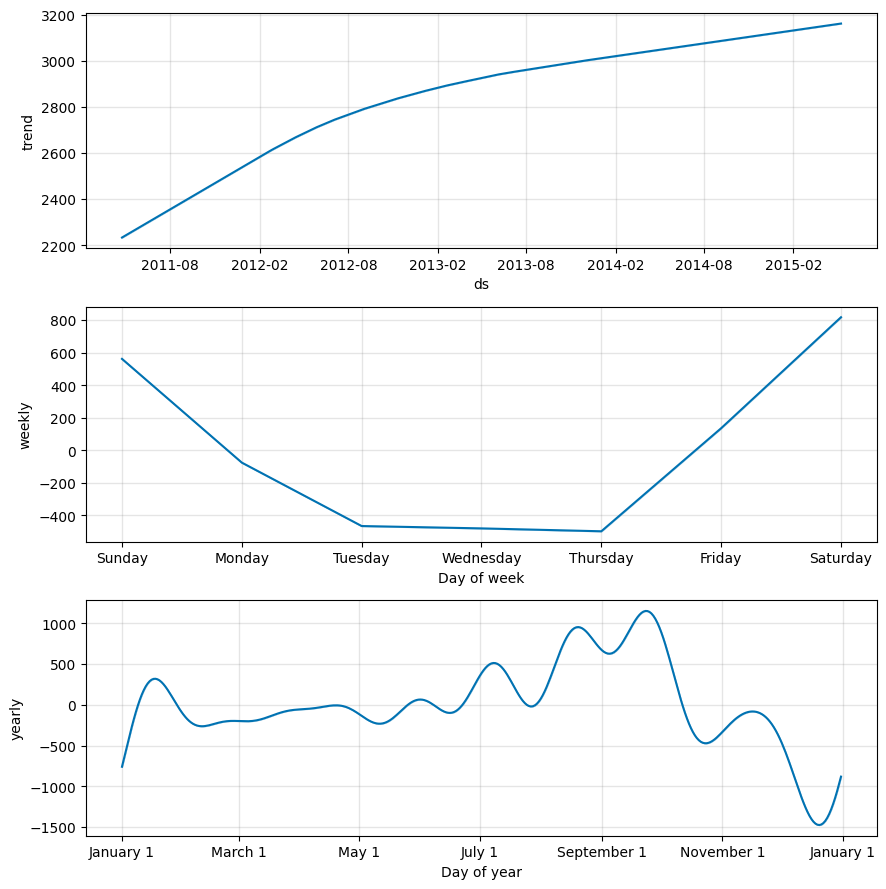

In [13]:
fig = model_prophet.plot_components(
    forecast
)

plt.show()

**8. Features para ML**

In [14]:
features = [
    "store_encoded",
    "cat_encoded",
    "month",
    "week",
    "quarter",
    "dayofweek",
    "is_weekend",
    "snap_CA",
    "snap_TX",
    "snap_WI",
    "event_encoded",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_56",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28",
    "trend_7",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos"
]

**9. Train/Test para ML**

In [15]:
X_train = train[features]

X_test = test[features]

y_train = train["sales"]

y_test = test["sales"]

**10. XGBoost**

In [16]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

Previsão:

In [17]:
xgb_pred = xgb_model.predict(
    X_test
)

Métricas:

In [18]:
xgb_mae, xgb_rmse = calculate_metrics(
    y_test,
    xgb_pred
)

print(
    xgb_mae,
    xgb_rmse
)

333.68206787109375 427.7547121306789


**11. LightGBM**

In [19]:
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 469
[LightGBM] [Info] Number of data points in the train set: 119, number of used features: 22
[LightGBM] [Info] Start training from score 2687.613445
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMRegressor(learning_rate=0.05, max_depth=6, n_estimators=500,
              random_state=42)

Previsão:

In [20]:
lgb_pred = lgb_model.predict(
    X_test
)

Métricas:

In [21]:
lgb_mae, lgb_rmse = calculate_metrics(
    y_test,
    lgb_pred
)

print(
    lgb_mae,
    lgb_rmse
)

365.1157521631029 446.43367807316537


**12. Comparação Final**

In [22]:
results = pd.DataFrame(
    {
        "Model": [
            "Naive",
            "Prophet",
            "XGBoost",
            "LightGBM"
        ],

        "MAE": [
            baseline_mae,
            prophet_mae,
            xgb_mae,
            lgb_mae
        ],

        "RMSE": [
            baseline_rmse,
            prophet_rmse,
            xgb_rmse,
            lgb_rmse
        ]
    }
)

results = results.sort_values(
    "MAE"
).reset_index(drop=True)

results

,Model,MAE,RMSE
0,XGBoost,333.682068,427.754712
1,LightGBM,365.115752,446.433678
2,Naive,530.571429,763.186412
3,Prophet,657.660530,863.565089


Salvando base:

In [23]:
results.to_csv(
    "model_metrics.csv",
    index=False
)

**13. Feature Importance (XGBoost)**

In [24]:
importance = pd.DataFrame(
    {
        "feature": features,
        "importance":
        xgb_model.feature_importances_
    }
)

importance = importance.sort_values(
    "importance",
    ascending=False
)

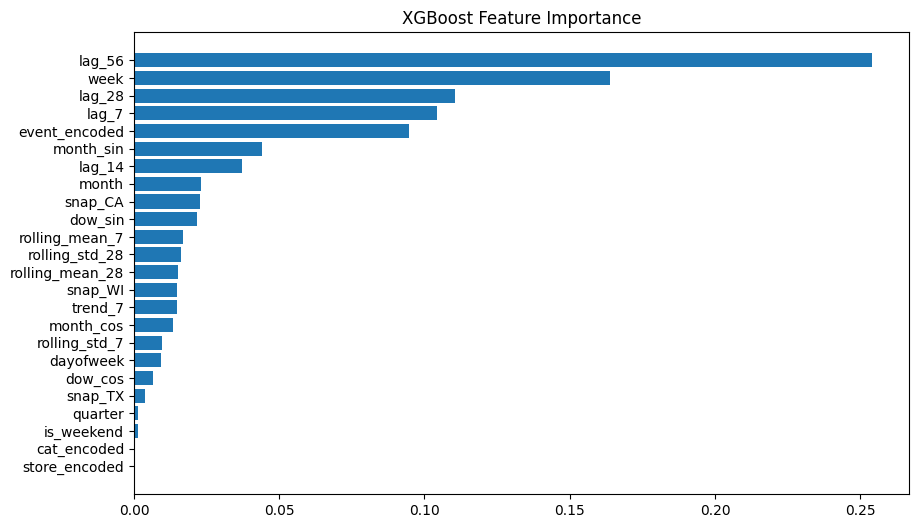

In [25]:
plt.figure(
    figsize=(10,6)
)

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

In [26]:
forecast_dates = test["date"].values

**14. Gráfico Comparativo**

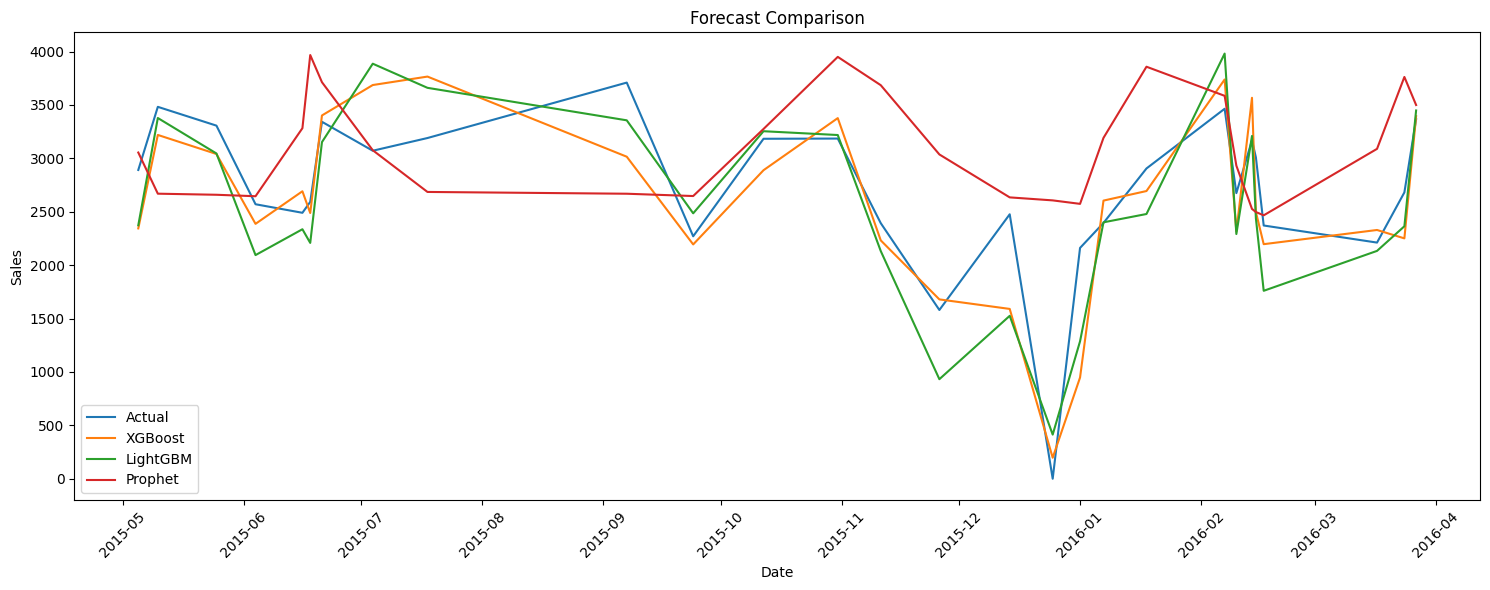

In [27]:
forecast_comparison = pd.DataFrame(
    {
        "Date": forecast_dates,
        "Actual": y_test.values,
        "XGBoost": xgb_pred,
        "LightGBM": lgb_pred,
        "Prophet": prophet_pred.values
    }
)

plt.figure(figsize=(15,6))

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["Actual"],
    label="Actual"
)

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["XGBoost"],
    label="XGBoost"
)

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["LightGBM"],
    label="LightGBM"
)

plt.plot(
    forecast_comparison["Date"],
    forecast_comparison["Prophet"],
    label="Prophet"
)

plt.title("Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [28]:
forecast_comparison["forecast"] = (
    forecast_comparison["XGBoost"]
)

forecast_comparison["Day"] = range(
    1,
    len(forecast_comparison)+1
)

In [29]:
forecast_comparison.head()

,Date,Actual,XGBoost,LightGBM,Prophet,forecast,Day
0,2015-05-05,2891,2343.853271,2373.293848,3054.219920,2343.853271,1
1,2015-05-10,3482,3218.961426,3377.397074,2668.880621,3218.961426,2
2,2015-05-25,3306,3040.518555,3045.385243,2658.734318,3040.518555,3
3,2015-06-04,2570,2386.462891,2093.909854,2645.002444,2386.462891,4
4,2015-06-16,2490,2691.539307,2335.932067,3282.045635,2691.539307,5


Salvando base:

In [30]:
forecast_comparison.to_csv(
    "forecast_results.csv",
    index=False
)

**15. Melhor Modelo**

In [31]:
best_model = (
    results
    .sort_values("MAE")
    .iloc[0]["Model"]
)

print(
    f"Best model: {best_model}"
)

Best model: XGBoost


In [32]:
import os

files = os.listdir('/kaggle/working')

print("Generated files:\n")

for file in files:
    print(file)

Generated files:

model_metrics.csv
forecast_results.csv
.virtual_documents


O Prophet foi utilizado como benchmark especializado para séries temporais, oferecendo interpretabilidade através da decomposição de tendência e sazonalidade. Entretanto, os modelos baseados em gradient boosting apresentaram melhor desempenho ao incorporar variáveis de calendário, eventos promocionais e estatísticas de demanda histórica.

Os forecasts produzidos servirão de entrada para o módulo de otimização de estoque (Notebook M5_Forecasting_Inventory_Opt), permitindo cálculo de Safety Stock, Reorder Point e Economic Order Quantity (EOQ).